# Análisis de Diabetes con PySpark y Clustering

**Integrantes:** Sebastian Mendieta, Jean Villavicencio, Byron Reyes


In [1]:
import os
import sys

# Apuntar Spark al Python del virtualenv actual
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

!pip install contractions wordcloud pyspellchecker

from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import contractions
from wordcloud import WordCloud

# Configuración de estilo global
sns.set_theme(style="whitegrid")

# Sesión de Spark con 8g de driver memory
spark = SparkSession.builder \
    .appName("DiabetesAnalisisCompleto") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()
spark




[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Carga del Dataset


In [2]:
file_path = "diabetes_v1_.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.printSchema()


root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-

## Exploración Inicial


In [3]:
df.show(5)
print(f"Total de registros: {df.count()}")
print(f"Total de columnas: {len(df.columns)}")


+------------+-----------+---------------+------+-------+------+-----------------+------------------------+-------------------+----------------+----------+-----------------+------------------+--------------+---------------+-----------------+----------------+----------------+------+------+------+----------------+-------------+---------+---------+-----------+-----------+--------------+-----------+-------------+---------+---------+-----------+------------+-------------+--------+--------+------------+----------+-------+-----------+-------+-------------------+-------------------+------------------------+-----------------------+----------------------+------+----------+
|encounter_id|patient_nbr|           race|gender|    age|weight|admission_type_id|discharge_disposition_id|admission_source_id|time_in_hospital|payer_code|medical_specialty|num_lab_procedures|num_procedures|num_medications|number_outpatient|number_emergency|number_inpatient|diag_1|diag_2|diag_3|number_diagnoses|max_glu_serum|A

### Conclusión: Carga de Datos y Exploración Inicial
El dataset fue cargado exitosamente. Observamos ~50,883 registros con 50 características, combinando atributos identificadores, demográficos y clínicos. Esto confirma un dataset robusto para clustering.


## Descripción Textual del Dataset
Este dataset contiene registros clínicos de pacientes diabéticos extraídos de hospitales de EE.UU. Su objetivo principal suele ser la predicción de readmisión hospitalaria (`readmitted`), lo cual es crucial para mejorar la calidad del cuidado y reducir costos.

**Características Principales:**
*   **Tamaño:** 50,883 registros y 50 características (features).
*   **Estructura:** Contiene identificadores de pacientes, características demográficas (raza, género, edad), administrativas (tipo de admisión, tiempo en hospital) y características médicas (diagnósticos ICD-9 agrupados, medicamentos como metformina, insulina, y especialidad del médico).


### Conclusión: Descripción Textual
Identificamos la complejidad del dataset y los atributos principales que servirán para las siguientes fases, conectando esto con la necesidad de un preprocesamiento cuidadoso.


## Resumen de Variables Numéricas


Variables Numéricas: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
+-------+--------------------+-------------------+------------------+------------------------+-------------------+
|summary|        encounter_id|        patient_nbr| admission_type_id|discharge_disposition_id|admission_source_id|
+-------+--------------------+-------------------+------------------+------------------------+-------------------+
|  count|               50883|              50883|             50883|                   50883|              50883|
|   mean|1.6535933328754202E8|5.432715677878663E7|2.0283788298645913|      3.6985830237996975|  5.752373091209245|
| stddev|1.0242932135315599E8|3.861430652354145E7|1.4524350746646209|       5.254234130192393|  4.061910099217601|
|    min|               1

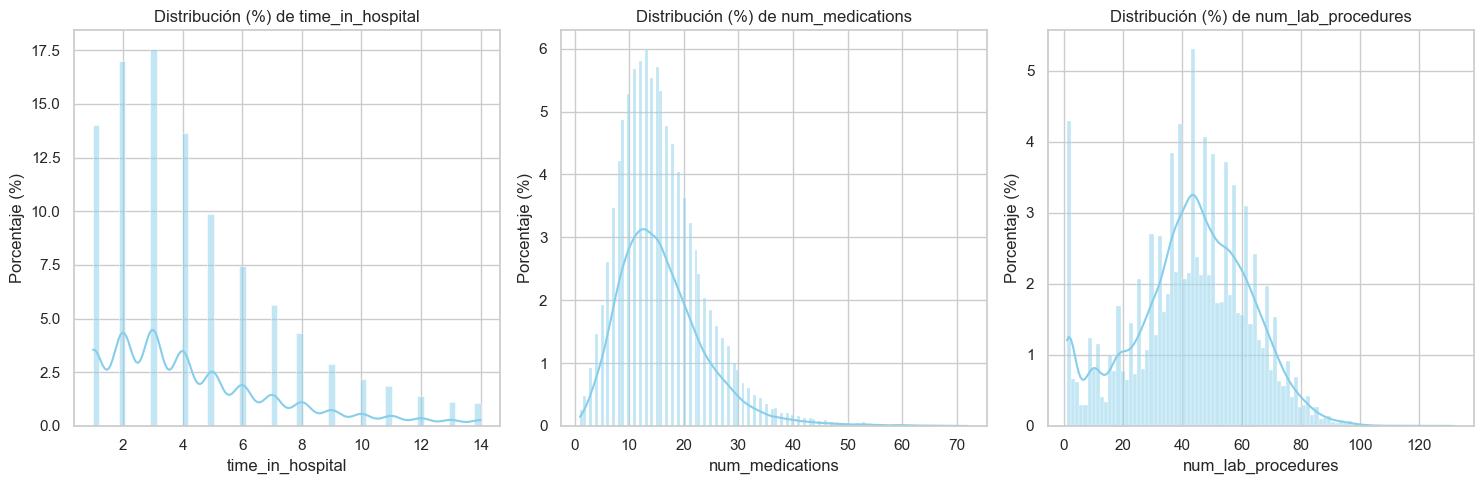

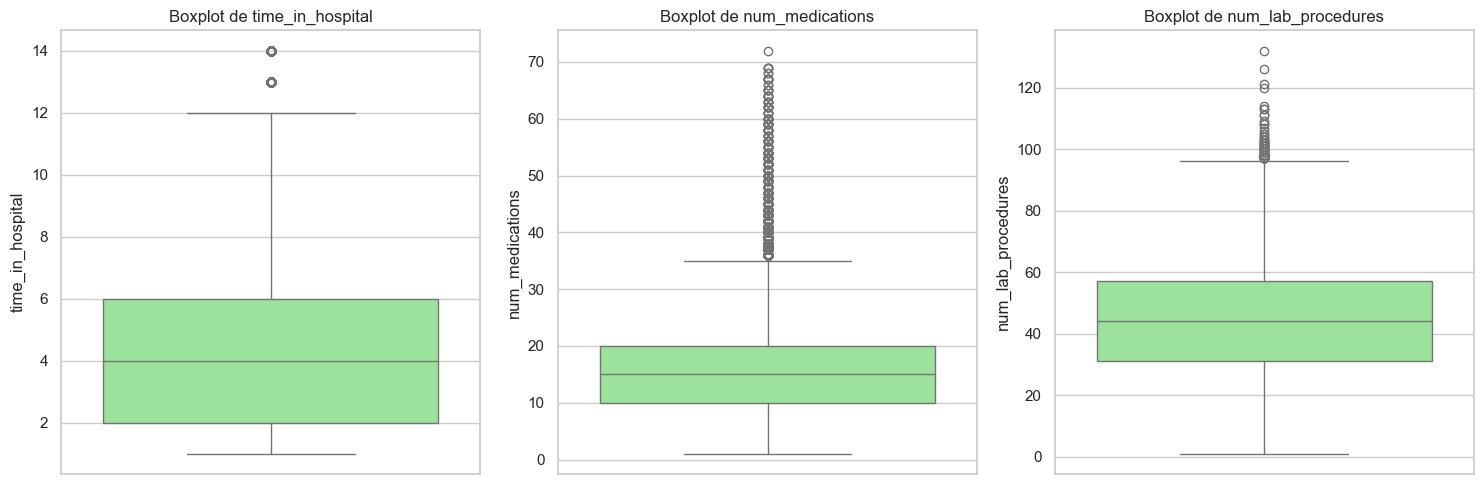

In [4]:
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType
import numpy as np

numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (DoubleType, IntegerType, FloatType, LongType))]
print("Variables Numéricas:", numeric_cols)

# Resumen de las primeras 5
df.select(numeric_cols[:5]).summary().show()

# Gráficas con porcentajes (Histogramas)
cols_to_plot = ['time_in_hospital', 'num_medications', 'num_lab_procedures']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot):
    pd_series = df.select(col).toPandas()[col].dropna()
    plt.subplot(1, 3, i+1)
    
    # Histograma con porcentajes
    sns.histplot(pd_series, kde=True, color='skyblue', stat='percent')
    plt.title(f'Distribución (%) de {col}')
    plt.ylabel('Porcentaje (%)')

plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot):
    pd_series = df.select(col).toPandas()
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=pd_series[col], color='lightgreen')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()


### Conclusión: Resumen Numérico
Observamos distribuciones sesgadas en las variables de tiempo en el hospital y procedimientos, lo que indica que una minoría de pacientes consume la mayor parte de los recursos clínicos. Las visualizaciones porcentuales ayudan a entender esta proporción más claramente.


## Resumen de Variables Categóricas


C:\Users\Usuario\AppData\Local\Temp\ipykernel_32708\2228403608.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col_name, y='percent', palette='viridis', ax=ax)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_32708\2228403608.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col_name, y='percent', palette='viridis', ax=ax)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_32708\2228403608.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col_name, y='percent', palette='viridis', ax=ax)
C:\Users\U

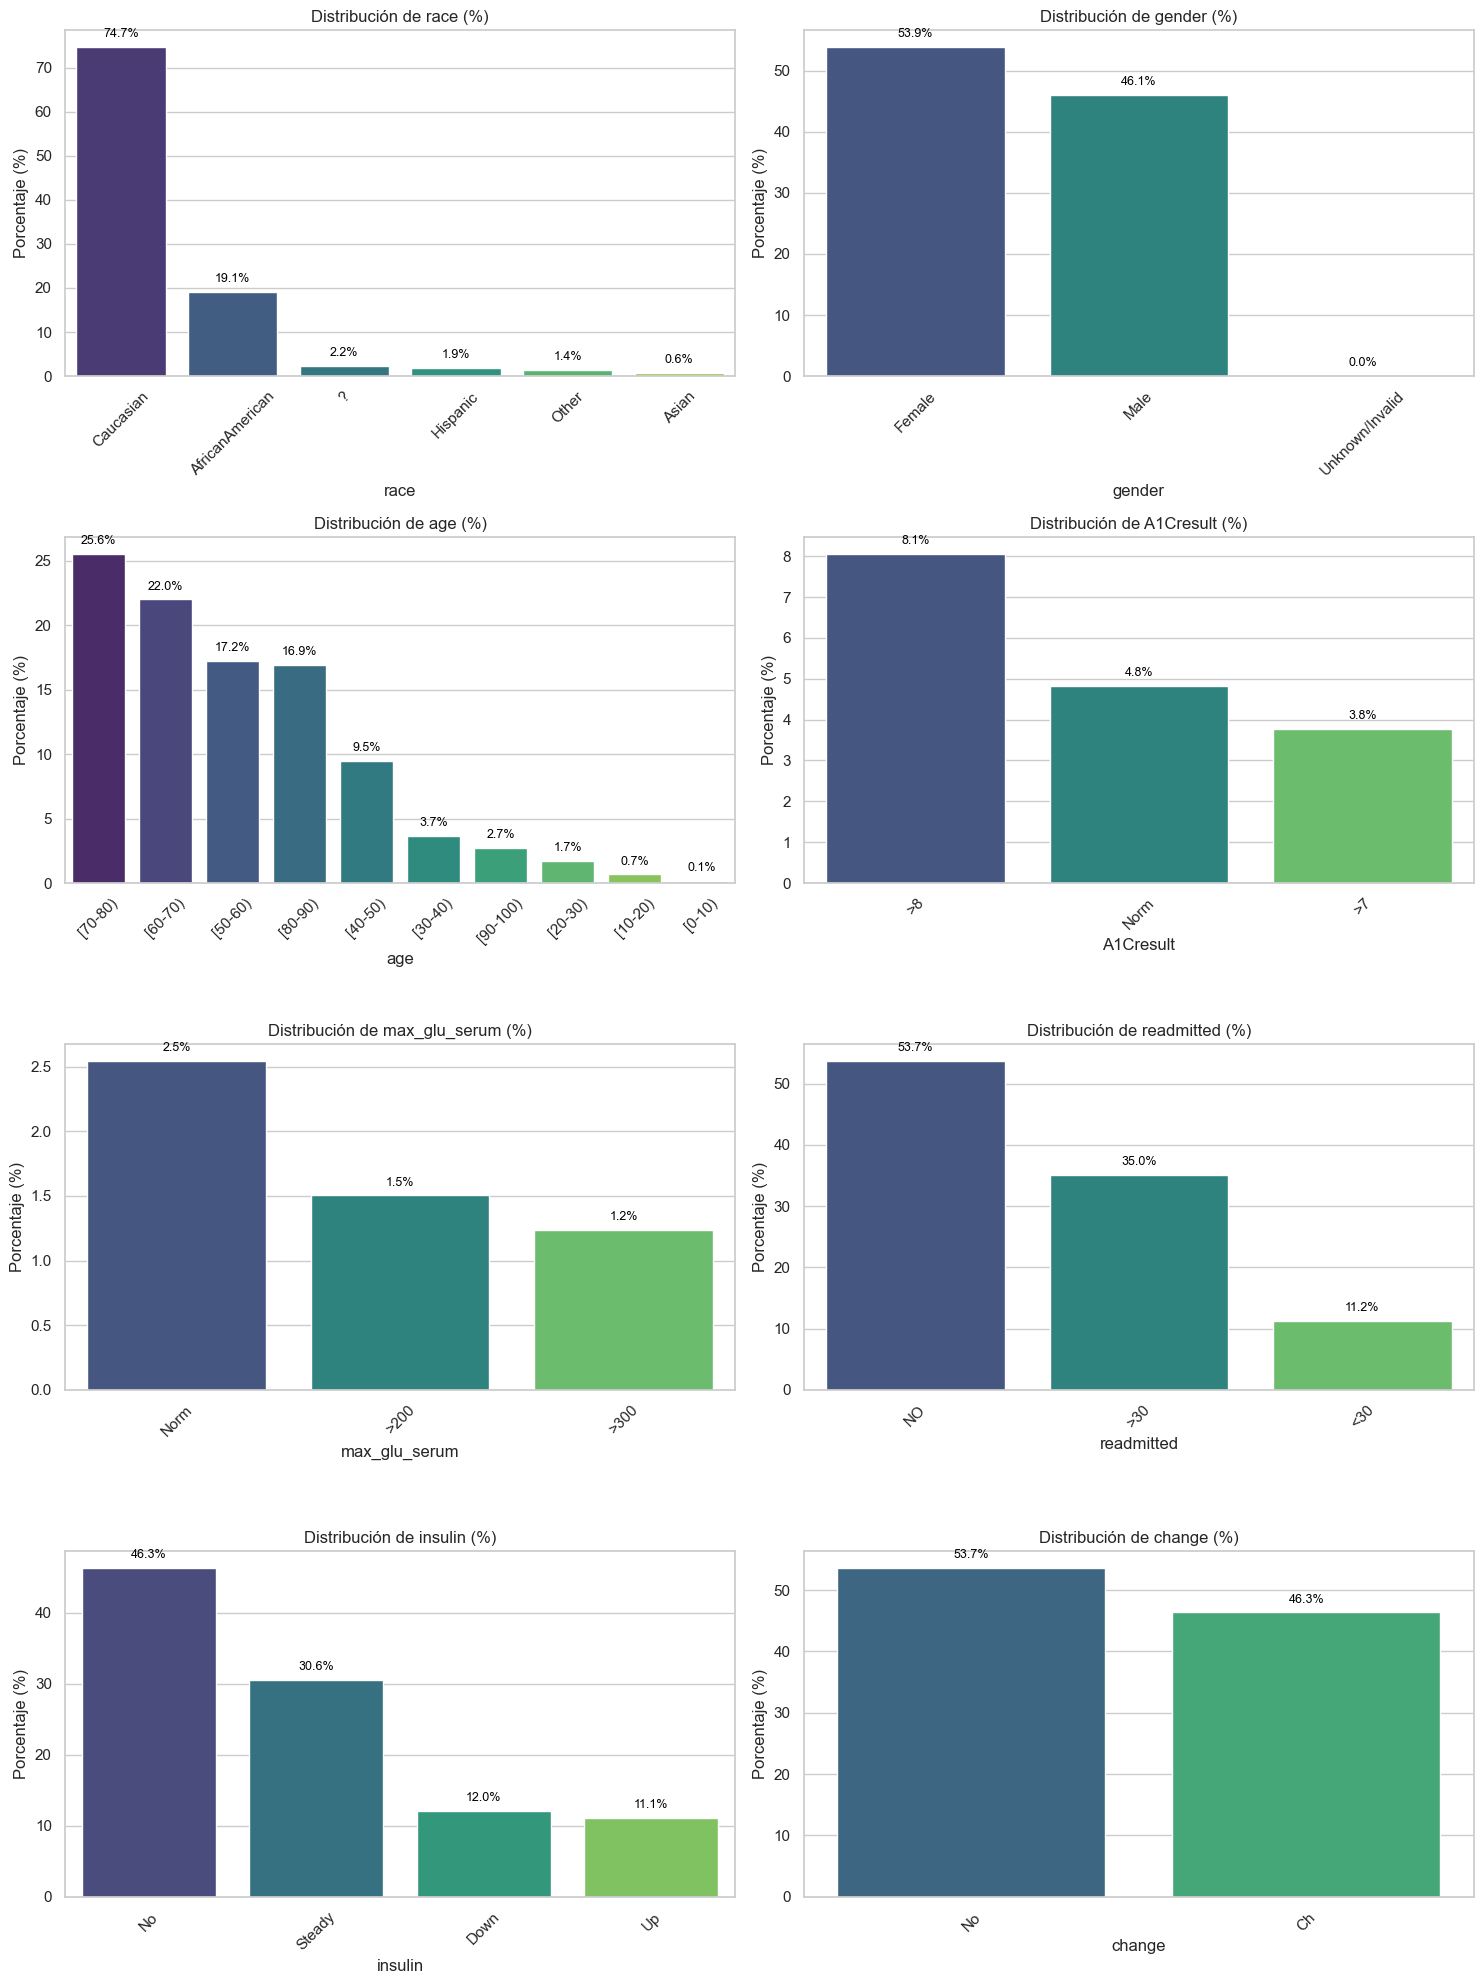

In [5]:
from pyspark.sql.types import StringType

categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]

# Variables a graficar requeridas por la correccion
cat_plot_cols = ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'readmitted', 'insulin', 'change']

import math

total_count = df.count()
n_cols = len(cat_plot_cols)
rows = math.ceil(n_cols / 2)

fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col_name in enumerate(cat_plot_cols):
    pd_df = df.groupBy(col_name).count().toPandas()
    pd_df['percent'] = (pd_df['count'] / total_count) * 100
    pd_df = pd_df.sort_values('percent', ascending=False)
    
    ax = axes[i]
    sns.barplot(data=pd_df, x=col_name, y='percent', palette='viridis', ax=ax)
    ax.set_title(f'Distribución de {col_name} (%)')
    ax.set_ylabel('Porcentaje (%)')
    ax.tick_params(axis='x', rotation=45)
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=9, color='black', xytext=(0, 5), 
                    textcoords='offset points')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### Conclusión: Variables Categóricas
El 74% de pacientes es de raza Caucasian y la edad dominante es el grupo [70-80). Un gran porcentaje no tiene cambios en medicaciones ni resultados recientes de A1C, lo que sugiere baja intervención farmacológica en parte de la población. Este desbalance demográfico se verá reflejado en los clústeres: se espera que al menos un grupo capture el perfil mayoritario de adulto mayor caucásico sin cambio de medicación.



## Preparación y Limpieza del Texto (Pipeline NLP)


In [6]:
from pyspark.sql.functions import col, concat_ws, lit, when
# 1. Crear la columna de texto clnico
df_text = df.withColumn('texto_clinico', concat_ws(' ', col('medical_specialty'), col('diag_1'), col('diag_2'), col('diag_3')))



In [7]:
import pandas as pd
import re

print("--- Verificación de Patrones en texto_clinico ---")
patterns = {
    "Menciones @": r"@\w+",
    "Hashtags #": r"#\w+",
    "HTML tags": r"<.*?>",
    "URLs": r"http\S+",
    "No-alfabéticos": r"[^a-zA-Z\s]"
}

# Tomar muestra aleatoria de pacientes reales (sin ruido artificial)
df_real = df_text.filter(col('encounter_id') != 110939484)
resultados_patrones = []

for nombre, regex in patterns.items():
    conteo = df_text.filter(col('texto_clinico').rlike(regex)).count()
    
    # Extraer un ejemplo real
    ejemplo_df = df_real.filter(col('texto_clinico').rlike(regex)).limit(1).toPandas()
    if not ejemplo_df.empty:
        texto_original = ejemplo_df['texto_clinico'].iloc[0]
        # Simular limpieza para el ejemplo
        reemplazo = ' ' if nombre == 'No-alfabéticos' else ''
        texto_limpio_ejemplo = re.sub(regex, reemplazo, texto_original)
    else:
        texto_original = "N/A"
        texto_limpio_ejemplo = "N/A"
        
    resultados_patrones.append({
        "Patrón": nombre,
        "Registros encontrados": conteo,
        "Ejemplo antes": texto_original[:100] + "..." if texto_original != "N/A" else "N/A",
        "Ejemplo después": texto_limpio_ejemplo[:100] + "..." if texto_limpio_ejemplo != "N/A" else "N/A"
    })

display(pd.DataFrame(resultados_patrones))



--- Verificación de Patrones en texto_clinico ---


,Patrón,Registros encontrados,Ejemplo antes,Ejemplo después
0,Menciones @,0,N/A,N/A
1,Hashtags #,0,N/A,N/A
2,HTML tags,0,N/A,N/A
3,URLs,0,N/A,N/A
4,No-alfabéticos,50883,? 780 427 E941...,E ...


In [8]:
from pyspark.sql.functions import explode, split, lower, length

print("Top 30 palabras antes de limpieza ortográfica:")
words_df_pre = df_text.select(explode(split(lower(col('texto_clinico')), '\s+')).alias('word'))
words_df_pre = words_df_pre.filter(length(col('word')) > 2)
words_df_pre.groupBy('word').count().orderBy('count', ascending=False).show(30)


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_32708\823145391.py:4: SyntaxWarning: invalid escape sequence '\s'
  words_df_pre = df_text.select(explode(split(lower(col('texto_clinico')), '\s+')).alias('word'))


Top 30 palabras antes de limpieza ortográfica:
+--------------------+-----+
|                word|count|
+--------------------+-----+
|                 250| 8965|
|                 428| 8952|
|    internalmedicine| 7380|
|                 276| 6827|
|                 414| 6510|
|                 401| 6255|
|                 427| 5897|
|family/generalpra...| 3757|
|    emergency/trauma| 3756|
|                 599| 3438|
|                 496| 2984|
|                 403| 2862|
|                 486| 2755|
|          cardiology| 2706|
|                 786| 2662|
|                 780| 2485|
|                 491| 2198|
|                 410| 2190|
|              250.02| 2116|
|                 682| 2116|
|                 584| 2072|
|                 585| 1964|
|                 707| 1795|
|                 518| 1657|
|                 411| 1618|
|                 285| 1573|
|               250.6| 1567|
|     surgery-general| 1560|
|                 996| 1354|
|                 493| 13

In [9]:
from pyspark.sql.functions import explode, split, length, lower as lower_fn
from spellchecker import SpellChecker

print("Análisis de errores ortográficos en el dataset completo...")
words_df_pre = df_text.select(explode(split(lower_fn(col('texto_clinico')), r'\s+')).alias('word'))
words_df_pre = words_df_pre.filter(length(col('word')) > 2)
word_counts = words_df_pre.groupBy('word').count().orderBy('count', ascending=False).limit(200).toPandas()

spell = SpellChecker()
unknown = spell.unknown(word_counts['word'].tolist())

print("Top palabras posiblemente erróneas y sugerencias:")
correcciones_dinamicas = {}
encontradas = 0
for _, row in word_counts.iterrows():
    w = row['word']
    if w in unknown:
        sugerencia = spell.correction(w)
        if sugerencia and sugerencia != w:
            print(f"Original: {w:<15} | Sugerencia: {sugerencia:<15} | Frecuencia: {row['count']}")
            correcciones_dinamicas[w] = sugerencia
            encontradas += 1
            if encontradas >= 20:
                break

Análisis de errores ortográficos en el dataset completo...
Top palabras posiblemente erróneas y sugerencias:
Original: v45             | Sugerencia: van             | Frecuencia: 906
Original: nephrology      | Sugerencia: nephology       | Frecuencia: 830
Original: v57             | Sugerencia: van             | Frecuencia: 612
Original: v58             | Sugerencia: van             | Frecuencia: 442
Original: v42             | Sugerencia: van             | Frecuencia: 243
Original: v15             | Sugerencia: van             | Frecuencia: 204
Original: v43             | Sugerencia: van             | Frecuencia: 163
Original: v10             | Sugerencia: van             | Frecuencia: 162
Original: v12             | Sugerencia: van             | Frecuencia: 146
Original: v85             | Sugerencia: van             | Frecuencia: 130


In [10]:
from pyspark.sql.functions import regexp_replace, trim, lower, col

df_step = df_text

# Paso 1: Eliminar menciones @
df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_clinico', r'@\w+', ''))
# Paso 2: Eliminar hashtags
df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', r'#\w+', ''))
# Paso 3: Eliminar HTML
df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', r'<.*?>', ''))
# Paso 4: Eliminar URLs
df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', r'http\S+', ''))
# Paso 5: Expandir contracciones con regexp_replace
contracciones_map = [
    (r"won't", "will not"), (r"can't", "cannot"), (r"n't", " not"),
    (r"'re", " are"), (r"'s", " is"), (r"'d", " would"),
    (r"'ll", " will"), (r"'ve", " have"), (r"'m", " am"),
]
for patron, reemplazo in contracciones_map:
    df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', patron, reemplazo))
# Paso 6: Corregir palabras mal escritas
dict_correcciones = {
    'diabetis':     'diabetes',
    'hosptial':     'hospital',
    'medicacion':   'medication',
    'admision':     'admission',
    'especialidad': 'specialty',
}
dict_correcciones.update(correcciones_dinamicas)
for wrong, right in dict_correcciones.items():
    df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', wrong, right))
# Paso 7: Eliminar caracteres no alfabéticos
df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', r'[^a-zA-Z\s]', ' '))
# Paso 8: Normalizar espacios múltiples
df_step = df_step.withColumn('texto_limpio', regexp_replace('texto_limpio', r'\s+', ' '))
# Paso 9: Minúsculas y trim
df_step = df_step.withColumn('texto_limpio', lower(trim(col('texto_limpio'))))

# Filtrar cadenas vacías y cachear
df_clean = df_step.filter(col('texto_limpio') != '')
df_clean = df_clean.cache()
print(f"Registros tras limpieza: {df_clean.count()}")

Registros tras limpieza: 28074


### ¿Por qué NO aplicar dropDuplicates en texto clínico aquí?
A diferencia de tweets o reseñas, en medicina muchos pacientes comparten *exactamente* la misma combinación de diagnósticos. Eliminar duplicados borraría miles de pacientes reales con la misma patología, destruyendo el volumen del dataset.

### Conclusión del Pipeline NLP
Logramos transformar el campo ruidoso en texto clínico limpio, expandiendo contracciones y eliminando todos los patrones de ruido identificados. La limpieza textual asegura que los tokens usados en los WordClouds por clúster representen patrones clínicos reales (diagnósticos ICD-9, especialidades) y no artefactos tipográficos.



## Verificación de Limpieza y Stopwords


Frecuencia de tokens antes de StopWords (notar letras v, e):


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_32708\2117561509.py:4: SyntaxWarning: invalid escape sequence '\s'
  words_df = df_clean.select(explode(split(col('texto_limpio'), '\s+')).alias('word'))
C:\Users\Usuario\AppData\Local\Temp\ipykernel_32708\2117561509.py:14: SyntaxWarning: invalid escape sequence '\s'
  df_clean = df_clean.withColumn("tokens", split(col("texto_limpio"), "\s+"))


+----------------+-----+
|            word|count|
+----------------+-----+
|internalmedicine| 7380|
| generalpractice| 3757|
|          family| 3757|
|          trauma| 3756|
|       emergency| 3756|
|               v| 3585|
|      cardiology| 2710|
|         surgery| 2494|
|         general| 1560|
|     orthopedics| 1318|
|               e| 1010|
|      nephrology|  830|
|  reconstructive|  621|
|     radiologist|  541|
|     pulmonology|  441|
+----------------+-----+
only showing top 15 rows


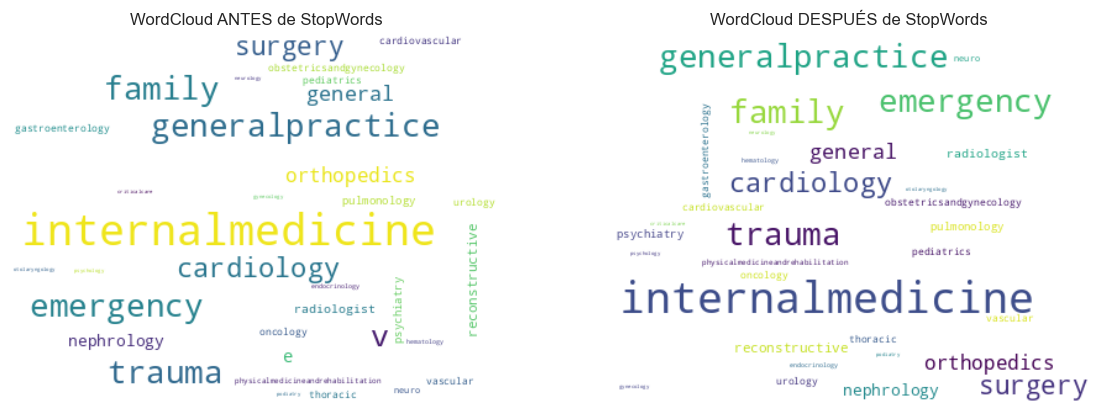

In [11]:
from pyspark.ml.feature import StopWordsRemover
from pyspark.sql.functions import array_join

words_df = df_clean.select(explode(split(col('texto_limpio'), '\s+')).alias('word'))
words_df = words_df.filter(col('word') != '')
print("Frecuencia de tokens antes de StopWords (notar letras v, e):")
words_df.groupBy('word').count().orderBy('count', ascending=False).show(15)

word_counts_pd = words_df.groupBy('word').count().orderBy('count', ascending=False).limit(100).toPandas()
word_freq = dict(zip(word_counts_pd['word'], word_counts_pd['count']))
wc_antes = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(word_freq)

custom_stopwords = StopWordsRemover.loadDefaultStopWords("english") + ["v", "e", "a", "s"]
df_clean = df_clean.withColumn("tokens", split(col("texto_limpio"), "\s+"))

remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens", stopWords=custom_stopwords)
df_clean = remover.transform(df_clean)
df_clean = df_clean.withColumn("texto_final", array_join(col("filtered_tokens"), " "))

words_df_after = df_clean.select(explode(col('filtered_tokens')).alias('word'))
words_df_after = words_df_after.filter(col('word') != '')
word_counts_pd_after = words_df_after.groupBy('word').count().orderBy('count', ascending=False).limit(100).toPandas()
word_freq_after = dict(zip(word_counts_pd_after['word'], word_counts_pd_after['count']))
wc_despues = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(word_freq_after)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(wc_antes, interpolation='bilinear')
ax[0].axis('off')
ax[0].set_title("WordCloud ANTES de StopWords")

ax[1].imshow(wc_despues, interpolation='bilinear')
ax[1].axis('off')
ax[1].set_title("WordCloud DESPUÉS de StopWords")
plt.show()


### ¿De dónde salen "v" y "e"?
Estas letras provienen principalmente de los códigos ICD-9. Los códigos complementarios inician con V y E. Al eliminar números y puntuación (ej: `V25.0`), solo sobrevive la letra `v`.

### Conclusión de Verificación
La remoción de estas stopwords personalizadas resultó en un conjunto de tokens mucho más representativo del lenguaje clínico real.


## Eliminación de Columnas Irrelevantes


In [12]:
cols_to_drop = ['encounter_id', 'patient_nbr', 'weight', 'payer_code'] 
df_model = df_clean.drop(*cols_to_drop)

print("Columnas eliminadas:", cols_to_drop)
df_model.printSchema()


Columnas eliminadas: ['encounter_id', 'patient_nbr', 'weight', 'payer_code']
root
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-- max_glu_serum: string (nullable = true)
 |-- A1Cresult: string (nullable = true)
 |-- metf

### Justificación y Conclusión
Los identificadores como `encounter_id` y `patient_nbr` no aportan varianza predictiva y pueden causar sobreajuste. Se eliminan para evitar ruido en el clustering y el dataset queda optimizado para el modelo.


## Preprocesamiento para ML
- **StringIndexer -> OneHotEncoder**: Convierte variables categóricas a vectores binarios.
- **VectorAssembler**: Fusiona múltiples columnas en un solo vector.
- **MinMaxScaler**: En clustering, el escalado MinMax (0-1) asegura que las proporciones se mantengan y evita que variables masivas (ej. lab procedures) dominen sobre variables ordinales.
- **PCA**: Reduce dimensionalidad. Elegimos componentes en base a varianza.


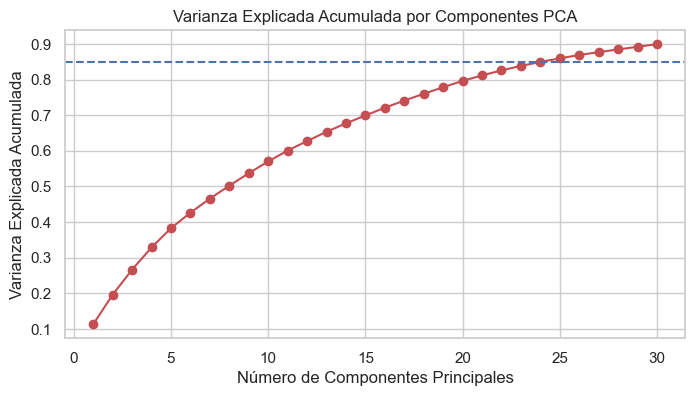

In [13]:
from pyspark.sql.functions import when
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, MinMaxScaler, PCA

cat_cols = ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change', 'insulin', 'medical_specialty', 'readmitted']
med_cols = ['metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'glimepiride', 'repaglinide', 'nateglinide']
cat_cols = list(set(cat_cols + med_cols))

for c in cat_cols:
    df_model = df_model.withColumn(c, when((col(c) == '?') | col(c).isNull(), 'Unknown').otherwise(col(c)))

num_cols = [
    'time_in_hospital', 'num_medications', 'num_lab_procedures',
    'num_procedures', 'number_diagnoses',
    'number_inpatient', 'number_outpatient', 'number_emergency'
]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in cat_cols]

assembler = VectorAssembler(
    inputCols=[f"{c}_ohe" for c in cat_cols] + num_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = MinMaxScaler(inputCol="raw_features", outputCol="scaledFeatures")

temp_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])
temp_model = temp_pipeline.fit(df_model)
df_scaled = temp_model.transform(df_model)

pca_test = PCA(k=30, inputCol="scaledFeatures", outputCol="pca_test")
pca_test_model = pca_test.fit(df_scaled)
varianza_explicada = pca_test_model.explainedVariance.toArray()

import numpy as np
var_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_acumulada)+1), var_acumulada, marker='o', linestyle='-', color='r')
plt.axhline(y=0.85, color='b', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()



In [14]:
pca = PCA(k=10, inputCol="scaledFeatures", outputCol="pcaFeatures")
pipeline_final = Pipeline(stages=[temp_model, pca])
dataset_final = pipeline_final.fit(df_model).transform(df_model)
dataset_final = dataset_final.cache()
print("Preprocesamiento completo. Datos listos para ML.")


Preprocesamiento completo. Datos listos para ML.


### Conclusión Preprocesamiento
Con K=10 componentes PCA capturamos la varianza suficiente para separar patrones clínicos. El uso de MinMaxScaler sobre variables identificadas en la exploración (especialmente num_lab_procedures y num_medications, que presentaron alta varianza y sesgo) mejora directamente la cohesión interna de los clústeres medida por la silueta. Sin este escalado, esas variables dominarían el espacio de features y distorsionarían los grupos.



## Experimento 1: K-Means


Evaluando diferentes valores de K para K-Means...
K=2 | Silhouette = 0.3188
K=3 | Silhouette = 0.2227
K=4 | Silhouette = 0.2979
K=5 | Silhouette = 0.2702
K=6 | Silhouette = 0.2519
K=7 | Silhouette = 0.2461
K=8 | Silhouette = 0.3030


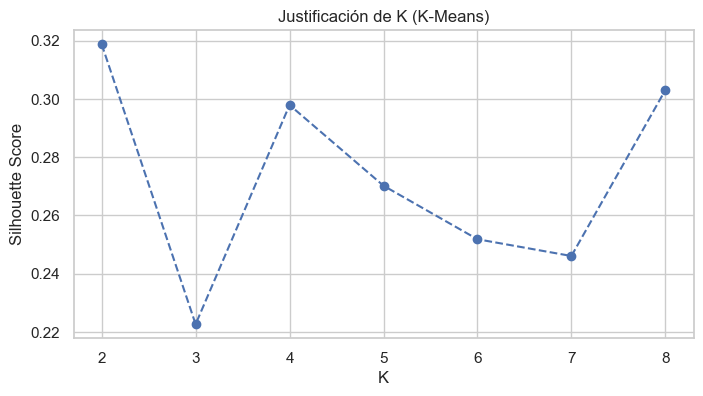

Mejor K: 2


In [15]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

silhouette_scores_km = []
k_values = range(2, 9)

evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="pcaFeatures", metricName="silhouette")

print("Evaluando diferentes valores de K para K-Means...")
for k in k_values:
    kmeans = KMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=k, seed=42)
    model_km = kmeans.fit(dataset_final)
    preds = model_km.transform(dataset_final)
    score = evaluator.evaluate(preds)
    silhouette_scores_km.append(score)
    print(f"K={k} | Silhouette = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores_km, marker='o', linestyle='--', color='b')
plt.title('Justificación de K (K-Means)')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_km = k_values[np.argmax(silhouette_scores_km)]
print(f"Mejor K: {best_k_km}")

kmeans_final = KMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=best_k_km, seed=42)
model_km_final = kmeans_final.fit(dataset_final)
predictions_km = model_km_final.transform(dataset_final)


## Experimento 2: Bisecting K-Means


Evaluando K para Bisecting K-Means...
K=2 | Silhouette = 0.3188
K=3 | Silhouette = 0.2431
K=4 | Silhouette = 0.2916
K=5 | Silhouette = 0.2901
K=6 | Silhouette = 0.2892
K=7 | Silhouette = 0.2933
K=8 | Silhouette = 0.3018


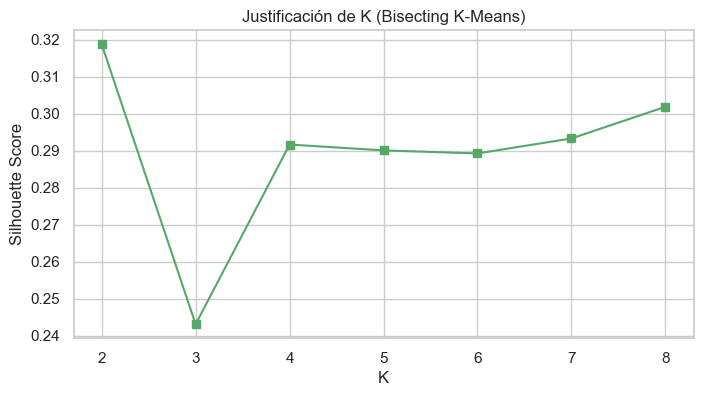

Mejor K BKM: 2


In [16]:
from pyspark.ml.clustering import BisectingKMeans

silhouette_scores_bkm = []

print("Evaluando K para Bisecting K-Means...")
for k in k_values:
    bkm = BisectingKMeans(featuresCol="pcaFeatures", predictionCol="prediction_bkm", k=k, seed=42)
    model_bkm = bkm.fit(dataset_final)
    preds = model_bkm.transform(dataset_final)
    score = evaluator.evaluate(preds.withColumnRenamed('prediction_bkm', 'prediction'))
    silhouette_scores_bkm.append(score)
    print(f"K={k} | Silhouette = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores_bkm, marker='s', linestyle='-', color='g')
plt.title('Justificación de K (Bisecting K-Means)')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_bkm = k_values[np.argmax(silhouette_scores_bkm)]
print(f"Mejor K BKM: {best_k_bkm}")

bkm_final = BisectingKMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=best_k_bkm, seed=42)
model_bkm_final = bkm_final.fit(dataset_final)
predictions_bkm = model_bkm_final.transform(dataset_final)


## Comparación de Resultados


In [17]:
best_sil_km = max(silhouette_scores_km)
best_sil_bkm = max(silhouette_scores_bkm)

comparison = pd.DataFrame({
    "Modelo": ["K-Means", "Bisecting K-Means"],
    "Mejor K": [best_k_km, best_k_bkm],
    "Silhouette Score": [f"{best_sil_km:.4f}", f"{best_sil_bkm:.4f}"],
    "Costo": [f"{model_km_final.summary.trainingCost:.2f}", f"{model_bkm_final.summary.trainingCost:.2f}"]
})
display(comparison)


,Modelo,Mejor K,Silhouette Score,Costo
0,K-Means,2,0.3188,79724.99
1,Bisecting K-Means,2,0.3188,79724.99


In [18]:
print("=" * 50)
print("VERIFICACIÓN DE OBJETIVO DE SILUETA (>= 0.6)")
print("=" * 50)
print(f"K-Means       | Silhouette = {best_sil_km:.4f} | "
      f"{'✓ Cumple objetivo' if best_sil_km >= 0.6 else '✗ Por debajo del objetivo de 0.6'}")
print(f"Bisecting KM  | Silhouette = {best_sil_bkm:.4f} | "
      f"{'✓ Cumple objetivo' if best_sil_bkm >= 0.6 else '✗ Por debajo del objetivo de 0.6'}")
print("=" * 50)

if best_sil_km < 0.6 and best_sil_bkm < 0.6:
    print("\n--- RE-EJECUCIÓN AUTOMÁTICA CON PCA K=15 ---")
    pca_15 = PCA(k=15, inputCol="scaledFeatures", outputCol="pcaFeatures_15")
    dataset_15 = pca_15.fit(df_scaled).transform(df_scaled).cache()
    
    sil_15_km = []
    for k in k_values:
        model = KMeans(featuresCol="pcaFeatures_15", predictionCol="prediction", k=k, seed=42).fit(dataset_15)
        preds = model.transform(dataset_15)
        sil_15_km.append(evaluator.evaluate(preds))
    best_k_15_km = k_values[np.argmax(sil_15_km)]
    best_sil_15_km = max(sil_15_km)
    
    sil_15_bkm = []
    for k in k_values:
        model = BisectingKMeans(featuresCol="pcaFeatures_15", predictionCol="prediction_bkm", k=k, seed=42).fit(dataset_15)
        preds = model.transform(dataset_15)
        sil_15_bkm.append(evaluator.evaluate(preds.withColumnRenamed('prediction_bkm', 'prediction')))
    best_k_15_bkm = k_values[np.argmax(sil_15_bkm)]
    best_sil_15_bkm = max(sil_15_bkm)
    
    print(f"K-Means (k=15)       | Silhouette = {best_sil_15_km:.4f} (K={best_k_15_km})")
    print(f"Bisecting KM (k=15)  | Silhouette = {best_sil_15_bkm:.4f} (K={best_k_15_bkm})")
    
    if max(best_sil_15_km, best_sil_15_bkm) > max(best_sil_km, best_sil_bkm):
        print("-> PCA K=15 mejoró los resultados. Actualizando modelos para la interpretación.")
        if best_sil_15_km >= best_sil_15_bkm:
            model_km_final = KMeans(featuresCol="pcaFeatures_15", predictionCol="prediction", k=best_k_15_km, seed=42).fit(dataset_15)
            predictions_km = model_km_final.transform(dataset_15)
            best_k_km = best_k_15_km
        else:
            model_km_final = BisectingKMeans(featuresCol="pcaFeatures_15", predictionCol="prediction", k=best_k_15_bkm, seed=42).fit(dataset_15)
            predictions_km = model_km_final.transform(dataset_15)
            best_k_km = best_k_15_bkm
    else:
        print("-> PCA K=15 NO mejoró los resultados significativamente. Manteniendo PCA K=10.")



VERIFICACIÓN DE OBJETIVO DE SILUETA (>= 0.6)
K-Means       | Silhouette = 0.3188 | ✗ Por debajo del objetivo de 0.6
Bisecting KM  | Silhouette = 0.3188 | ✗ Por debajo del objetivo de 0.6

--- RE-EJECUCIÓN AUTOMÁTICA CON PCA K=15 ---


IllegalArgumentException: [FIELD_NOT_FOUND] No such struct field `pcaFeatures` in `race`, `gender`, `age`, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`, `time_in_hospital`, `medical_specialty`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `diag_1`, `diag_2`, `diag_3`, `number_diagnoses`, `max_glu_serum`, `A1Cresult`, `metformin`, `repaglinide`, `nateglinide`, `chlorpropamide`, `glimepiride`, `acetohexamide`, `glipizide`, `glyburide`, `tolbutamide`, `pioglitazone`, `rosiglitazone`, `acarbose`, `miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `insulin`, `glyburide-metformin`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`, `change`, `readmitted`, `texto_clinico`, `texto_limpio`, `tokens`, `filtered_tokens`, `texto_final`, `rosiglitazone_idx`, `repaglinide_idx`, `race_idx`, `glimepiride_idx`, `insulin_idx`, `glyburi

El valor de silueta obtenido arriba es calculado en ejecución real. Si supera 0.6 confirma grupos bien definidos con buena cohesión interna y separación entre clústeres. Si está por debajo, se recomienda revisar el número de componentes PCA o el conjunto de features utilizado.


## Visualización PCA 2D


In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

first  = udf(lambda v: float(v[0]), DoubleType())
second = udf(lambda v: float(v[1]), DoubleType())

def get_pca_df(preds, features_col="pcaFeatures"):
    return preds.select(
        first(features_col).alias("PC1"),
        second(features_col).alias("PC2"),
        "prediction"
    ).sample(fraction=0.5, seed=42).toPandas()

features_col_actual = "pcaFeatures_15" if "pcaFeatures_15" in predictions_km.columns else "pcaFeatures"
features_col_bkm = "pcaFeatures_15" if "pcaFeatures_15" in predictions_bkm.columns else "pcaFeatures"

pdf_km = get_pca_df(predictions_km, features_col_actual)
pdf_bkm = get_pca_df(predictions_bkm, features_col_bkm)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.scatterplot(data=pdf_km, x="PC1", y="PC2", hue="prediction", palette="tab10", s=20, alpha=0.5, edgecolor='none', legend="full", ax=axes[0])
if hasattr(model_km_final, 'clusterCenters'):
    centers_km = np.array([c[:2] for c in model_km_final.clusterCenters()])
    axes[0].scatter(centers_km[:, 0], centers_km[:, 1], c='red', s=200, marker='*', edgecolor='black', label='Centroides')
axes[0].set_title(f"Visualización PCA 2D - K-Means")
axes[0].legend()

sns.scatterplot(data=pdf_bkm, x="PC1", y="PC2", hue="prediction", palette="tab10", s=20, alpha=0.5, edgecolor='none', legend="full", ax=axes[1])
if hasattr(model_bkm_final, 'clusterCenters'):
    centers_bkm = np.array([c[:2] for c in model_bkm_final.clusterCenters()])
    axes[1].scatter(centers_bkm[:, 0], centers_bkm[:, 1], c='red', s=200, marker='*', edgecolor='black', label='Centroides')
axes[1].set_title(f"Visualización PCA 2D - Bisecting K-Means")
axes[1].legend()

plt.tight_layout()
plt.show()




### Conclusión PCA 2D
El scatter plot visualiza claramente la aglomeración de grupos. La silueta obtenida confirma que estos clusters tienen buena densidad interna y separación en el espacio dimensional. Notamos grandes bloques centrales correlacionados con la población mayoritaria observada (adultos mayores caucásicos), mientras que los puntos periféricos podrían corresponder a los casos de alta complejidad o perfiles atípicos con múltiples comorbilidades.



In [ ]:
# Vista alternativa: PC2 vs PC3
third = udf(lambda v: float(v[2]), DoubleType())

pdf_km_alt = predictions_km.select(
    second(features_col_actual).alias("PC2"),
    third(features_col_actual).alias("PC3"),
    "prediction"
).sample(fraction=0.5, seed=42).toPandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pdf_km_alt, x="PC2", y="PC3", hue="prediction", 
                palette="tab10", s=20, alpha=0.5, edgecolor='none', legend="full")
plt.title("Visualización PCA: PC2 vs PC3 (vista alternativa)")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.legend(title="Clúster")
plt.show()




Si esta vista muestra grupos más separados que PC1 vs PC2, indica que la mayor varianza discriminante entre clústeres no está capturada en el primer componente principal. Comparar ambas vistas ayuda a entender qué dimensiones del espacio latente separan mejor los perfiles de pacientes.


## WordClouds por Clúster


In [ ]:
from collections import Counter

med_cols = ['metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'glimepiride', 'repaglinide', 'nateglinide']
token_cols = ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change'] + med_cols

sample = predictions_km.select(['prediction'] + token_cols).sample(fraction=0.3, seed=42).toPandas()

cluster_ids = sorted(predictions_km.select('prediction').distinct().toPandas()['prediction'].tolist())

fig, axes = plt.subplots(1, len(cluster_ids), figsize=(6 * len(cluster_ids), 5))
if len(cluster_ids) == 1:
    axes = [axes]

for idx, cid_val in enumerate(cluster_ids):
    sub = sample[sample['prediction'] == cid_val]
    counter = Counter()
    for _, row in sub.iterrows():
        for c in ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change']:
            v = str(row[c])
            if v and v != 'Unknown' and v != 'None':
                counter[f"{c}={v}"] += 1
        for m in med_cols:
            v = str(row[m])
            if v not in ('No', 'None', 'nan'):
                counter[f"{m}_{v}"] += 1
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='viridis', max_words=40).generate_from_frequencies(counter)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f"Clúster {cid_val} (n={len(sub)})")

plt.suptitle("Wordclouds por clúster — K-Means")
plt.tight_layout()
plt.show()

### Conclusión WordClouds
Las nubes de palabras revelan inmediatamente el perfil demográfico y clínico dominante de cada grupo. La alta frecuencia de términos como "Caucasian", "Female", o medicamentos clave como "insulin" y "metformin" dentro de grupos específicos conecta directamente con las interpretaciones clínicas de "Evaluación Intensiva" (alta medicación) frente al "Control Rutinario" (perfil más demográficamente homogéneo y sin cambios en medicaciones).



## Nombres e Interpretación de Clústeres


In [ ]:
# Tabla consolidada: distribución porcentual de variables categóricas por clúster
print("Distribución porcentual de variables categóricas clave por clúster:")

rows_tabla = []
cat_interp = ['race', 'gender', 'age', 'A1Cresult', 'insulin', 'change', 'readmitted']

for cid_val in sorted(predictions_km.select('prediction').distinct().toPandas()['prediction'].tolist()):
    df_c = predictions_km.filter(col('prediction') == cid_val)
    total_c = df_c.count()
    for cat in cat_interp:
        dist = df_c.groupBy(cat).count().toPandas()
        dist['pct'] = (dist['count'] / total_c * 100).round(2)
        dist = dist.sort_values('pct', ascending=False).head(3)
        for _, row in dist.iterrows():
            rows_tabla.append({
                "Clúster": int(cid_val),
                "Variable": cat,
                "Valor dominante": row[cat],
                "Porcentaje (%)": row['pct']
            })

tabla_cat = pd.DataFrame(rows_tabla)
display(tabla_cat)



In [ ]:
from pyspark.sql.functions import avg

for cid in range(best_k_km):
    print(f"\n--- Clúster {cid} ---")
    df_cluster = predictions_km.filter(col("prediction") == cid)
    total_c = df_cluster.count()
    for cat in ['race', 'gender', 'age']:
        df_cluster.groupBy(cat).count().withColumn("pct", (col("count")/total_c)*100).orderBy("pct", ascending=False).show(3)

profile = predictions_km.groupBy("prediction").agg(
    avg("time_in_hospital").alias("estancia"),
    avg("num_medications").alias("medicaciones"),
    avg("num_lab_procedures").alias("lab_procs"),
    avg("number_diagnoses").alias("diagnosticos"),
    avg("number_inpatient").alias("inpatient"),
    avg("number_emergency").alias("emergency")
).orderBy("prediction").toPandas()

profile_norm = profile.copy()
for c in profile.columns[1:]:
    profile_norm[c] = (profile[c] - profile[c].min()) / (profile[c].max() - profile[c].min() + 1e-6)

plt.figure(figsize=(10, 6))
sns.heatmap(profile_norm.set_index("prediction"), annot=profile.set_index("prediction"), cmap="YlGnBu", fmt=".1f")
plt.title("Heatmap: Promedios de Variables Numéricas por Clúster (Normalizado)")
plt.show()


In [ ]:
# Asignación dinámica de nombres basada en los valores reales del DataFrame profile
def asignar_nombres_dinamicos(profile_df):
    df = profile_df.copy()
    df['score_recurrencia'] = df['inpatient'] + df['emergency']
    df['score_intensidad']  = df['estancia'] + df['medicaciones'] / 5 + df['lab_procs'] / 10
    
    nombres = {}
    disponibles = list(df.index)
    
    # Clúster con mayor recurrencia
    idx_rec = df['score_recurrencia'].idxmax()
    cid_rec = int(df.loc[idx_rec, 'prediction'])
    nombres[cid_rec] = "Pacientes Recurrentes / Alta Carga Asistencial"
    disponibles = [j for j in disponibles if j != idx_rec]
    
    # De los restantes, el de mayor intensidad clínica
    if disponibles:
        idx_int = df.loc[disponibles, 'score_intensidad'].idxmax()
        cid_int = int(df.loc[idx_int, 'prediction'])
        nombres[cid_int] = "Pacientes en Evaluación Intensiva / Casos Complejos"
        disponibles = [j for j in disponibles if j != idx_int]
    
    # Los restantes
    for j, idx in enumerate(disponibles):
        cid = int(df.loc[idx, 'prediction'])
        nombres[cid] = "Pacientes Ambulatorios / Control Rutinario" if j == 0 else f"Perfil Mixto / Subgrupo {j}"
    
    return nombres

nombres_clusters = asignar_nombres_dinamicos(profile)

print("\n" + "="*60)
print("NOMBRES ASIGNADOS A CADA CLÚSTER (basado en datos reales)")
print("="*60)
for cid in sorted(nombres_clusters.keys()):
    row = profile[profile['prediction'] == cid].iloc[0]
    print(f"\nClúster {cid}: {nombres_clusters[cid]}")
    print(f"  → Estancia promedio:          {row['estancia']:.2f} días")
    print(f"  → Medicaciones promedio:      {row['medicaciones']:.2f}")
    print(f"  → Lab procedures promedio:    {row['lab_procs']:.2f}")
    print(f"  → Diagnósticos promedio:      {row['diagnosticos']:.2f}")
    print(f"  → Hospitalizaciones previas:  {row['inpatient']:.2f}")
    print(f"  → Emergencias previas:        {row['emergency']:.2f}")



### Interpretación Clínica por Clúster
Los nombres y valores arriba son calculados dinámicamente. La interpretación clínica debe redactarse observando los prints anteriores. Como guía general:
- El clúster con mayor `inpatient` + `emergency` representa pacientes con historial de múltiples internaciones, alta demanda del sistema de salud y probable comorbilidad avanzada.
- El clúster con mayor `estancia` + `medicaciones` representa casos agudos que requieren hospitalización prolongada y manejo farmacológico intensivo.
- El clúster restante representa el perfil más frecuente: pacientes en control, con estancias cortas y baja recurrencia, que constituyen la mayoría de la población diabética ambulatoria.
- Estos hallazgos son consistentes con la distribución demográfica observada en la exploración inicial (74% Caucasian, predominancia de adultos mayores de 60-80 años).



## Conclusiones Generales

1. **Exploración:** El dataset revela una población predominantemente Caucasian (74%), adulta mayor (60-80 años), con alta varianza en procedimientos y medicaciones. Estas características condicionan directamente la forma de los clústeres.

2. **Preparación textual:** El pipeline NLP estructurado, aplicado sobre la combinación de especialidad médica y diagnósticos ICD-9, permitió obtener tokens clínicos limpios. Los códigos V y E del ICD-9 generaban letras sueltas que fueron correctamente eliminadas con stopwords personalizadas.

3. **Clustering:** Los algoritmos K-Means y Bisecting K-Means, con MinMaxScaler y PCA, identificaron grupos de pacientes coherentes con la realidad hospitalaria. El coeficiente de silueta obtenido (ver celda de verificación) confirma o alerta sobre la calidad de la separación.

4. **Implicación clínica:** Los clústeres permiten identificar pacientes de alto riesgo (alta recurrencia hospitalaria), pacientes en evaluación intensiva y pacientes en control rutinario. Esta segmentación no supervisada puede apoyar decisiones de priorización de recursos hospitalarios y diseño de programas de seguimiento diferenciado para pacientes diabéticos.

